# Housing Prices Prediction Pipeline

This project builds an end-to-end machine learning pipeline to predict housing prices using structured data.


## DATA OVERVIEW (EDA)

Examine the shape of the data, the feature types, and summarize missing data

In [4]:
# make sure this notebook can find the paths to the other directories
import os
import sys
sys.path.append(os.path.abspath(".."))

# using pandas DataFrame
import pandas as pd

# read Ames house pricing csv into DataFrame structure
df = pd.read_csv("../data/raw/ames_house_prices.csv")

# show the first 10 lines of the table
df.head(10)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
5,6,50,RL,85.0,14115,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,MnPrv,Shed,700,10,2009,WD,Normal,143000
6,7,20,RL,75.0,10084,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,307000
7,8,60,RL,NaN,10382,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,Shed,350,11,2009,WD,Normal,200000
8,9,50,RM,51.0,6120,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2008,WD,Abnorml,129900
9,10,190,RL,50.0,7420,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,1,2008,WD,Normal,118000


In [5]:
# describe the size of the data set (rows,columns)
df.shape

(1460, 81)

In [6]:
# list column names and data type
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

In [21]:
# give statistics of the target variable
df["SalePrice"].describe()

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

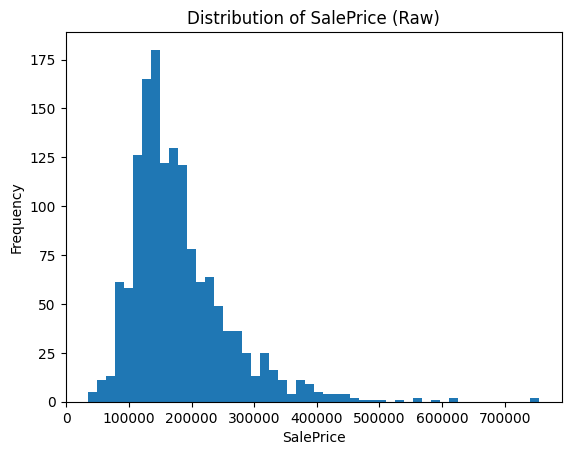

In [8]:
# show distribution of target variable values as a histogram
import matplotlib.pyplot as plt

plt.figure()
plt.hist(df["SalePrice"], bins=50)
plt.title("Distribution of SalePrice (Raw)")
plt.xlabel("SalePrice")
plt.ylabel("Frequency")
plt.show()

Histogram plot of SalePrice is right-skewed. To make the distribution look more gaussian, use the log values

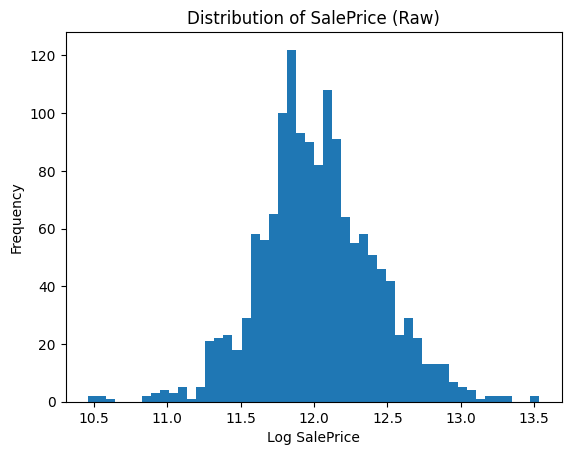

In [9]:
import numpy as np

plt.figure()
plt.hist(np.log1p(df["SalePrice"]), bins=50)
plt.title("Distribution of SalePrice (Raw)")
plt.xlabel("Log SalePrice")
plt.ylabel("Frequency")
plt.show()

In [10]:
# identify categories with missing values
missing = df.isnull().sum()
missing = missing[missing > 0]

missing_percent = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    "Missing Count": missing,
    "Missing %": missing_percent
}).sort_values(by="Missing %", ascending=False)

missing_df.head(20)

,Missing Count,Missing %
PoolQC,1453,99.520548
MiscFeature,1406,96.301370
Alley,1369,93.767123
Fence,1179,80.753425
MasVnrType,872,59.726027
FireplaceQu,690,47.260274
LotFrontage,259,17.739726
GarageType,81,5.547945
GarageYrBlt,81,5.547945
GarageFinish,81,5.547945


<Figure size 640x480 with 0 Axes>

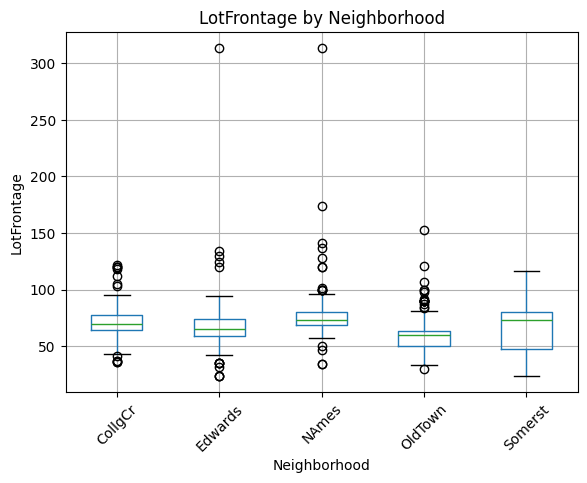

In [11]:
# Examine LotFrontage

# pick top neighborhoods
top_neighborhoods = df["Neighborhood"].value_counts().index[:5]

subset = df[df["Neighborhood"].isin(top_neighborhoods)]

plt.figure()
subset.boxplot(column="LotFrontage", by="Neighborhood")
plt.title("LotFrontage by Neighborhood")
plt.suptitle("")  # removes automatic title
plt.xlabel("Neighborhood")
plt.ylabel("LotFrontage")
plt.xticks(rotation=45)
plt.show()

## Assumptions from Exploratory Data Analysis

Data cleaning decisions were guided by patterns observed during exploratory analysis.

- Features with missing values representing the absence of a property characteristic (e.g., pool, alley access, fence, fireplace, garage, basement features, and masonry veneer type) were imputed with `"None"` to indicate non-existence.

- The `MasVnrArea` feature was set to 0 for missing values, as null entries correspond to properties without masonry veneer.

- The `GarageYrBlt` feature was set to 0 for missing values, as these entries correspond to properties without a garage.

- The `Electrical` feature is expected to be present for all homes; therefore, missing values were treated as data entry errors and imputed using the most frequent category.

- The `LotFrontage` feature is assumed to be present for all properties, but its distribution varies by neighborhood. Missing values were imputed using the median value within each neighborhood to preserve local structure.

- The `MiscFeature` column contains a high proportion of missing values (~96%) and was removed due to its limited contribution to predictive performance.

## Data Cleaning

Missing values were handled based on feature semantics:

- Categorical features representing absence were filled with "None"
- Numerical features representing absence were filled with 0
- Location-dependent features (e.g., LotFrontage) were imputed using grouped medians
- Remaining categorical values were imputed using the mode

Low-information features were removed.

In [12]:
from src.data_cleaning import clean_data

df = clean_data(df)

## Feature Engineering

New features were constructed to better capture relationships between housing characteristics and sale price

- **Age**: Calculated as the difference between the sale year and year built, capturing property age
- **Remodel Age**: Time since last renovation, reflecting updated condition
- **Total Square Footage (TotalSF)**: Combined basement and above-ground living space to represent total usable area
- **Total Bathrooms (TotalBath)**: Aggregated full and half bathrooms into a single feature
- **Quality × Living Area (Qual_x_SF)**: Interaction term between overall quality and living area to capture nonlinear effects

These features were designed based on domain intuition and observed relationships in the data
This allows models to better represent size, condition, and interaction effects

In [13]:
from src.feature_engineering import add_features

df = add_features(df)

# check new features
df[["TotalSF", "Age", "TotalBath", "Qual_x_SF"]].head()

,TotalSF,Age,TotalBath,Qual_x_SF
0,2566,5,3.5,11970
1,2524,31,2.5,7572
2,2706,7,3.5,12502
3,2473,91,2.0,12019
4,3343,8,3.5,17584


## Feature Encoding

Categorical variables were converted into numerical format using one-hot encoding

This process creates binary indicator variables for each category, allowing machine learning models to interpret categorical features

To avoid multicollinearity, one category per feature was dropped

In [14]:
X = df.drop("SalePrice", axis=1)
y = df["SalePrice"]

X_encoded = pd.get_dummies(X, drop_first=True)

# X_encoded.isnull().sum().sort_values(ascending=False).head(10)

## Model Training

Three regression models were evaluated:

- **Linear Regression** as a baseline model
- **Random Forest Regressor** to capture nonlinear relationships and feature interactions
- **Gradient Boosting Regressor** to improve predictive performance by sequentially correcting residual errors

Model performance was evaluated using **Root Mean Squared Error (RMSE)** on a held-out test set

Because the target variable was log-transformed, RMSE is reported in log space.

In [15]:
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd

from src.model_training import (
    train_linear_regression,
    train_random_forest,
    train_gradient_boosting,
    compute_rmse
)

# use log of target and split the data
y_log = np.log1p(y)

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y_log, test_size=0.2, random_state=42
)

In [16]:
# train the linear regression
linear_model = train_linear_regression(X_train, y_train)
y_pred_lin = linear_model.predict(X_test)
rmse_lin = compute_rmse(y_test, y_pred_lin)

rmse_lin

np.float64(0.177780876985426)

In [22]:
# train the random forest regressor
rf_model = train_random_forest(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
rmse_rf = compute_rmse(y_test, y_pred_rf)

rmse_rf

np.float64(0.1454114129524703)

In [23]:
# train the gradient boosting regressor
gbr_model = train_gradient_boosting(X_train, y_train)
y_pred_gbr = gbr_model.predict(X_test)
rmse_gbr = compute_rmse(y_test, y_pred_gbr)

rmse_gbr

np.float64(0.14204106614637282)

In [19]:
## Evaluation

# Compare the results of the models
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "Gradient Boosting"
    ],
    "RMSE_log": [
        rmse_lin,
        rmse_rf,
        rmse_gbr
    ]
})

results["Approx Error %"] = (np.exp(results["RMSE_log"]) - 1) * 100
results["RMSE_log"] = results["RMSE_log"].round(3)
results["Approx Error %"] = results["Approx Error %"].round(2)
results

,Model,RMSE_log,Approx Error %
0,Linear Regression,0.178,19.46
1,Random Forest,0.145,15.65
2,Gradient Boosting,0.142,15.26


### Model Evaluation

Ensemble tree-based models significantly outperformed linear regression, reducing prediction error from approximately 19% to around 15%.

This improvement indicates that housing prices depend on nonlinear relationships and feature interactions that are not well captured by a linear model.

Random Forest and Gradient Boosting both performed strongly, with Gradient Boosting achieving the best overall performance. 
This is expected, as boosting methods iteratively correct residual errors and are better suited for capturing complex patterns in structured data.

Overall, the results demonstrate that incorporating nonlinear models and feature engineering leads to substantial gains in predictive accuracy.
The relatively small performance gap between Random Forest and Gradient Boosting suggests that much of the predictive signal is already captured 
through feature engineering and tree-based partitioning, with diminishing returns from further model complexity.

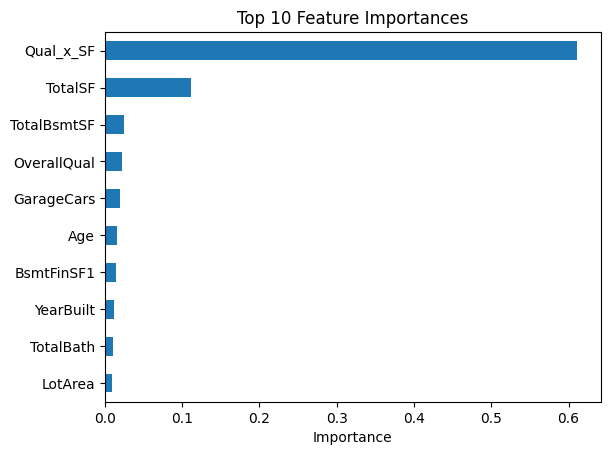

In [20]:
## Feature Importance

# Extract feature importances from Random Forest
feature_importances = pd.Series(
    rf_model.feature_importances_,
    index=X_encoded.columns
).sort_values(ascending=False)

import matplotlib.pyplot as plt

plt.figure()
feature_importances.head(10).plot(kind="barh")
plt.gca().invert_yaxis()
plt.title("Top 10 Feature Importances")
plt.xlabel("Importance")
plt.show()

### Feature Importance

Feature importance analysis from the Random Forest model highlights the primary drivers of housing prices.

The most influential feature is **Overall Quality**, indicating that construction and finish quality have the largest impact on property value. 
Measures of living space, such as **GrLivArea** and **Total Square Footage**, are also strong predictors, reflecting the importance of usable area.

Garage-related features and total bathroom count further contribute to price, capturing aspects of functionality and convenience.

These results are consistent with real-world expectations, where price is primarily driven by a combination of quality, size, and utility. 
The importance rankings also validate the feature engineering choices, particularly the inclusion of aggregated and interaction features.

The dominance of a small number of features suggests that a large portion of the predictive signal is concentrated in key structural attributes of the property.

## Conclusions

- Ensemble models outperform linear regression
- Feature engineering improves performance
- Final model achieves ~15% prediction error